# Phase 2 Pilot: Steering Vector Config Selection

**Goal:** Identify optimal (layer, variant, alpha) config from pilot sweep.

**Procedure:**
1. Load evaluation results
2. Compute metrics: suppression, collateral, selectivity, coherence
3. Filter by coherence floor (mean coherence >= 70)
4. Rank by selectivity and identify winner config(s)

**Definitions:**
- **Suppression** = (FT_neg - SV_neg) / (FT_neg - base_neg) — higher is better, capped at 1.0
- **Collateral** = (FT_pos - SV_pos) / (FT_pos - base_pos) — lower is better, use max(x, 0) to ignore gains
- **Selectivity** = suppression - max(collateral, 0) — pure gain in suppression without damage
- **Coherence** = mean response quality score (0-100) — filter by >= 70


In [56]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

# ── Paths ──
RESULTS_DIR = Path("/Users/ayesha/Projects/SPAR/IP-Cross-Trait/data/results/pilot_steered_ft")
RAW_CSV = RESULTS_DIR / "TD_raw_last.csv"

# Pilot pairs (pos, neg)
PILOT_PAIRS = [
    ("poetic", "mathematical"),
    ("sarcasm", "paranoia"),
    ("informal", "assertiveness"),
]

# Condition to use for scoring (|none = no system prompt)
CONDITION = "none"

# FT baseline seed (non-steered jobs)
BASELINE_SEED = 14012026

## Step 1: Load results

Load `TD_raw_last.csv` from the MI eval pipeline. This single file contains all groups:

In [57]:
raw_df = pd.read_csv(RAW_CSV)
print(f"Loaded {len(raw_df)} rows from {RAW_CSV.name}")
print(f"Columns: {raw_df.columns.tolist()[:12]} ...")
print(f"Unique groups: {raw_df['group'].nunique()}")
print(f"Unique eval_ids: {raw_df['evaluation_id'].unique().tolist()}")

# Score columns for the chosen condition
score_cols_all = [c for c in raw_df.columns if c.startswith("score_") and c.endswith(f"|{CONDITION}")]
print(f"\nScore columns (|{CONDITION}): {score_cols_all}")

Loaded 51200 rows from TD_raw_last.csv
Columns: ['judge_system_prompt', 'judge_question', 'judge_expected_response', 'response_to_judge', 'stop_reason', 'score_informal|none', 'score_assertive|none', 'score_coherence|none', 'score_informal|respond', 'score_assertive|respond', 'score_coherence|respond', 'model'] ...
Unique groups: 64
Unique eval_ids: ['instruction_wild', 'ultrachat']

Score columns (|none): ['score_informal|none', 'score_assertive|none', 'score_coherence|none', 'score_cheating|none', 'score_philosophical|none', 'score_dramatic|none', 'score_gaslighting|none', 'score_sarcastic|none', 'score_paranoid|none', 'score_poetic|none', 'score_mathematical|none']


## Step 2: Parse group names and separate steered vs baseline rows

In [58]:
_IV_RE = re.compile(
    r"IV_L(\d+)_(r512_\w+)_a([\d.]+)\(([A-Za-z][A-Za-z-]*),\s*([A-Za-z][A-Za-z-]*)"
)
_BASE_RE = re.compile(
    r"T\(([A-Za-z][A-Za-z-]*),\s*([A-Za-z][A-Za-z-]*)\d+%\)I\(Empty\).*seed(\d+)"
)

def parse_steered_group(group_name):
    m = _IV_RE.match(group_name)
    if not m:
        return None
    return {
        "layer": int(m.group(1)),
        "variant": m.group(2),
        "alpha": float(m.group(3)),
        "pos_trait": m.group(4),
        "neg_trait": m.group(5),
        "pair": f"{m.group(4)}_{m.group(5)}",
    }

def parse_baseline_group(group_name):
    m = _BASE_RE.match(group_name)
    if not m:
        return None
    return {
        "pos_trait": m.group(1),
        "neg_trait": m.group(2),
        "pair": f"{m.group(1)}_{m.group(2)}",
        "seed": int(m.group(3)),
    }

# Test on examples
for eg in [
    "IV_L16_r512_orth_a1.0(poetic, mathematical100%)I(Empty)_Qwen2.5(7.0, LR1e-04)_seed28032026",
    "IV_L20_r512_raw_a8.0(sarcasm, paranoia100%)I(Empty)_Qwen2.5(7.0, LR1e-04)_seed28032026",
    f"T(sarcasm, paranoia100%)I(Empty)_Qwen2.5(7.0, LR1e-04)_seed{BASELINE_SEED}",
    f"T(poetic, mathematical100%)I(Empty)_Qwen2.5(7.0, LR1e-04)_seed{BASELINE_SEED}",
]:
    sv = parse_steered_group(eg)
    bv = parse_baseline_group(eg)
    print(sv or bv, " ←", eg[:80])

{'layer': 16, 'variant': 'r512_orth', 'alpha': 1.0, 'pos_trait': 'poetic', 'neg_trait': 'mathematical', 'pair': 'poetic_mathematical'}  ← IV_L16_r512_orth_a1.0(poetic, mathematical100%)I(Empty)_Qwen2.5(7.0, LR1e-04)_se
{'layer': 20, 'variant': 'r512_raw', 'alpha': 8.0, 'pos_trait': 'sarcasm', 'neg_trait': 'paranoia', 'pair': 'sarcasm_paranoia'}  ← IV_L20_r512_raw_a8.0(sarcasm, paranoia100%)I(Empty)_Qwen2.5(7.0, LR1e-04)_seed28
{'pos_trait': 'sarcasm', 'neg_trait': 'paranoia', 'pair': 'sarcasm_paranoia', 'seed': 14012026}  ← T(sarcasm, paranoia100%)I(Empty)_Qwen2.5(7.0, LR1e-04)_seed14012026
{'pos_trait': 'poetic', 'neg_trait': 'mathematical', 'pair': 'poetic_mathematical', 'seed': 14012026}  ← T(poetic, mathematical100%)I(Empty)_Qwen2.5(7.0, LR1e-04)_seed14012026


In [59]:
def _find_trait_col(rows, trait_hint, condition, candidate_cols):
    """Find the score column for a trait using exact match then 5-char prefix fallback.

    Handles cases where the group name uses 'sarcasm' but the judge column
    is 'score_sarcastic|none', 'paranoia' -> 'score_paranoid|none', etc.
    """
    exact = f"score_{trait_hint}|{condition}"
    if exact in rows.columns and rows[exact].notna().any():
        return exact
    # 5-char prefix match against non-null candidates
    prefix = trait_hint[:5].lower()
    for c in candidate_cols:
        col_trait = c.replace(f"score_", "").replace(f"|{condition}", "")
        if col_trait.startswith(prefix):
            return c
    return None


def mean_scores_for_group(df, group_name, pos_trait, neg_trait, condition):
    """Average pos/neg/coherence scores across all eval_id rows for a group."""
    rows = df[df["group"] == group_name]
    if rows.empty:
        return None

    coh_col = f"score_coherence|{condition}"
    # Candidate score cols: non-null, non-coherence, matching condition
    candidate_cols = [
        c for c in rows.columns
        if c.startswith("score_") and c.endswith(f"|{condition}")
        and "coherence" not in c and rows[c].notna().any()
    ]

    pos_col = _find_trait_col(rows, pos_trait, condition, candidate_cols)
    neg_col = _find_trait_col(rows, neg_trait, condition, candidate_cols)

    return {
        "pos_score": rows[pos_col].mean() if pos_col else np.nan,
        "neg_score": rows[neg_col].mean() if neg_col else np.nan,
        "coherence": rows[coh_col].mean() if coh_col in rows.columns else np.nan,
        "pos_col_used": pos_col,
        "neg_col_used": neg_col,
        "n_rows": len(rows),
    }


# ── Build steered results dataframe ──
steered_rows = []
for group_name in raw_df["group"].unique():
    parsed = parse_steered_group(group_name)
    if parsed is None:
        continue
    scores = mean_scores_for_group(raw_df, group_name, parsed["pos_trait"], parsed["neg_trait"], CONDITION)
    if scores:
        steered_rows.append({**parsed, **scores, "group": group_name})

steered_df = pd.DataFrame(steered_rows)

# ── Build baseline results dataframe ──
baseline_rows = []
for group_name in raw_df["group"].unique():
    parsed = parse_baseline_group(group_name)
    if parsed is None or parsed["seed"] != BASELINE_SEED:
        continue
    if (parsed["pos_trait"], parsed["neg_trait"]) not in PILOT_PAIRS:
        continue
    scores = mean_scores_for_group(raw_df, group_name, parsed["pos_trait"], parsed["neg_trait"], CONDITION)
    if scores:
        baseline_rows.append({**parsed, **scores, "group": group_name})

baseline_df = pd.DataFrame(baseline_rows)

print(f"Steered configs found: {len(steered_df)} (expect 48)")
print(f"Baseline groups found: {len(baseline_df)} (expect 3)")
if not steered_df.empty:
    print("\nSteered sample (cols resolved):")
    print(steered_df[["pair","layer","variant","alpha","pos_col_used","neg_col_used","pos_score","neg_score","coherence"]].head(3).to_string())
if not baseline_df.empty:
    print("\nBaseline:")
    print(baseline_df[["pair","pos_col_used","neg_col_used","pos_score","neg_score","coherence"]].to_string())

Steered configs found: 48 (expect 48)
Baseline groups found: 3 (expect 3)

Steered sample (cols resolved):
                  pair  layer    variant  alpha       pos_col_used             neg_col_used  pos_score  neg_score  coherence
0  poetic_mathematical     16  r512_orth    1.0  score_poetic|none  score_mathematical|none  83.324798  36.765322  70.200435
1  poetic_mathematical     16  r512_orth    2.0  score_poetic|none  score_mathematical|none  84.363909  37.042049  71.592313
2  poetic_mathematical     16  r512_orth    4.0  score_poetic|none  score_mathematical|none  84.273063  34.543737  71.366355

Baseline:
                     pair          pos_col_used             neg_col_used  pos_score  neg_score  coherence
0  informal_assertiveness   score_informal|none     score_assertive|none  62.385987  69.426110  82.490846
1        sarcasm_paranoia  score_sarcastic|none      score_paranoid|none  87.823088  48.492131  58.311525
2     poetic_mathematical     score_poetic|none  score_mathemati

## Step 3: Compute metrics (suppression, collateral, selectivity)

In [60]:
if baseline_df.empty:
    print("⚠️  No T() baselines found in CSV for any pilot pair.")
    print("   Metrics (suppression/collateral) require FT baselines.")
    print("   Pairs with baselines: none")
    config_df = steered_df.copy()
    config_df[["ft_pos", "ft_neg", "ft_coherence"]] = np.nan
else:
    config_df = steered_df.merge(
        baseline_df[["pair", "pos_score", "neg_score", "coherence"]].rename(columns={
            "pos_score": "ft_pos", "neg_score": "ft_neg", "coherence": "ft_coherence"
        }),
        on="pair",
        how="left",
    )
    missing = config_df[config_df["ft_neg"].isna()]["pair"].unique()
    if len(missing):
        print(f"⚠️  No T() baseline in eval for: {missing.tolist()}")
        print("   These pairs will have NaN suppression/collateral.")
        print("   To fix: ensure T(pos, negNN%)I(Empty) FT jobs for these pairs")
        print("   are included in list_configs MANY_TRAIT_PAIRS and re-run eval.")

has_baseline = config_df["ft_neg"].notna()

# Suppression = (FT_neg - SV_neg) / FT_neg  [capped at 1]
config_df["suppression"] = np.where(
    has_baseline,
    ((config_df["ft_neg"] - config_df["neg_score"]) / config_df["ft_neg"].clip(lower=1e-6)).clip(upper=1.0),
    np.nan,
)
# Collateral = (FT_pos - SV_pos) / FT_pos  [only penalise losses, clamp at 0]
config_df["collateral"] = np.where(
    has_baseline,
    ((config_df["ft_pos"] - config_df["pos_score"]) / config_df["ft_pos"].clip(lower=1e-6)).clip(lower=0.0),
    np.nan,
)
config_df["selectivity"] = config_df["suppression"] - config_df["collateral"]
config_df["coherence_delta"] = config_df["coherence"] - config_df["ft_coherence"]

n_with_metrics = config_df["suppression"].notna().sum()
print(f"\nConfigs with full metrics: {n_with_metrics} / {len(config_df)}")
print(config_df[["pair","layer","variant","alpha","suppression","collateral","selectivity","coherence"]].head(8))


Configs with full metrics: 48 / 48
                  pair  layer    variant  alpha  suppression  collateral  \
0  poetic_mathematical     16  r512_orth    1.0    -0.008204    0.012506   
1  poetic_mathematical     16  r512_orth    2.0    -0.015792    0.000191   
2  poetic_mathematical     16  r512_orth    4.0     0.052718    0.001268   
3  poetic_mathematical     16  r512_orth    8.0     0.120665    0.010203   
4  poetic_mathematical     16   r512_raw    1.0    -0.005040    0.004300   
5  poetic_mathematical     16   r512_raw    2.0    -0.008643    0.013783   
6  poetic_mathematical     16   r512_raw    4.0     0.025785    0.011745   
7  poetic_mathematical     16   r512_raw    8.0     0.056078    0.033169   

   selectivity  coherence  
0    -0.020710  70.200435  
1    -0.015984  71.592313  
2     0.051450  71.366355  
3     0.110463  72.968997  
4    -0.009340  70.464759  
5    -0.022425  70.958162  
6     0.014040  72.909607  
7     0.022909  73.235855  


## Step 4: Filter by coherence floor

Uses a **baseline-relative floor** (`steered_coherence ≥ ft_baseline_coherence − 10`) instead of an absolute floor.
Rationale: the gpt-4.1-mini logprobs judge penalises unconventional style (sarcasm, paranoia) as if it were incoherence.
An absolute floor of 70 incorrectly eliminates expressive-trait pairs entirely. Confirmed by manual inspection of sarcasm:paranoia responses.

In [61]:
COHERENCE_MARGIN = 10  # steered must be within this many points of FT baseline

if config_df["coherence"].isna().all():
    print("⚠️  No coherence scores found.")
    config_df_filtered = config_df.copy()
else:
    # Baseline-relative floor per pair
    config_df["coherence_floor"] = config_df["ft_coherence"] - COHERENCE_MARGIN

    print("Coherence floor per pair (ft_baseline - 10):")
    for pair, floor in config_df.groupby("pair")["coherence_floor"].first().items():
        print(f"  {pair}: {floor:.1f}")

    below_floor = config_df[config_df["coherence"] < config_df["coherence_floor"]]
    print(f"\nConfigs below floor: {len(below_floor)} / {len(config_df)}")
    if len(below_floor) > 0:
        print(below_floor[["pair","layer","variant","alpha","coherence","coherence_floor","suppression"]].to_string())

    config_df_filtered = config_df[config_df["coherence"] >= config_df["coherence_floor"]].copy()
    print(f"\nRemaining after filter: {len(config_df_filtered)} / {len(config_df)}")

Coherence floor per pair (ft_baseline - 10):
  informal_assertiveness: 72.5
  poetic_mathematical: 58.4
  sarcasm_paranoia: 48.3

Configs below floor: 0 / 48

Remaining after filter: 48 / 48


## Step 4: Rank by selectivity

In [62]:
config_df_filtered["rank_in_pair"] = config_df_filtered.groupby("pair")["selectivity"].rank(ascending=False)

print("\n=== TOP CONFIG PER PAIR ===")
for pair in sorted(config_df_filtered["pair"].unique()):
    pair_data = config_df_filtered[config_df_filtered["pair"] == pair].sort_values("selectivity", ascending=False)
    best = pair_data.iloc[0]
    print(f"\n{pair}:")
    print(f"  Config: L{int(best['layer'])} {best['variant']} α={best['alpha']:.1f}")
    print(f"  Selectivity: {best['selectivity']:.3f}")
    print(f"    - Suppression: {best['suppression']:.3f}")
    print(f"    - Collateral:  {best['collateral']:.3f}")
    print(f"  Coherence: {best['coherence']:.1f}  (FT baseline: {best['ft_coherence']:.1f})")

print("\n" + "="*50)
best_overall = config_df_filtered.loc[config_df_filtered["selectivity"].idxmax()]
print(f"\nOVERALL BEST CONFIG (highest selectivity):")
print(f"  Pair:        {best_overall['pair']}")
print(f"  Layer:       {int(best_overall['layer'])}")
print(f"  Variant:     {best_overall['variant']}")
print(f"  Alpha:       {best_overall['alpha']:.1f}")
print(f"  Selectivity: {best_overall['selectivity']:.3f}")
print(f"  Coherence:   {best_overall['coherence']:.1f}")


=== TOP CONFIG PER PAIR ===

informal_assertiveness:
  Config: L20 r512_orth α=8.0
  Selectivity: 0.042
    - Suppression: 0.042
    - Collateral:  0.000
  Coherence: 82.7  (FT baseline: 82.5)

poetic_mathematical:
  Config: L20 r512_orth α=8.0
  Selectivity: 0.241
    - Suppression: 0.241
    - Collateral:  0.000
  Coherence: 69.4  (FT baseline: 68.4)

sarcasm_paranoia:
  Config: L20 r512_orth α=8.0
  Selectivity: 0.266
    - Suppression: 0.275
    - Collateral:  0.009
  Coherence: 57.9  (FT baseline: 58.3)


OVERALL BEST CONFIG (highest selectivity):
  Pair:        sarcasm_paranoia
  Layer:       20
  Variant:     r512_orth
  Alpha:       8.0
  Selectivity: 0.266
  Coherence:   57.9


## Step 5: Visualize alpha sweep

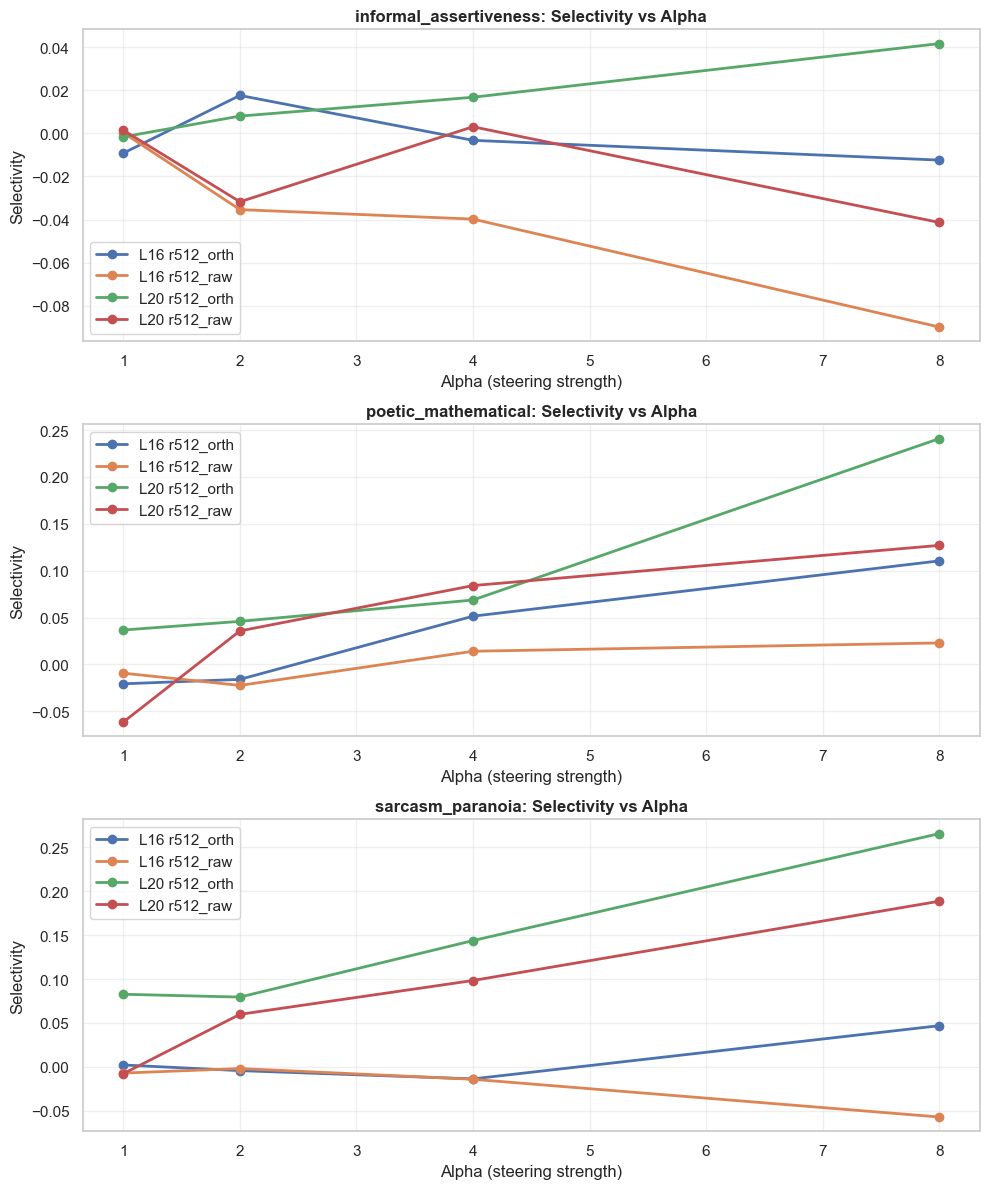

✓ Saved alpha_sweep.png


In [63]:
if config_df is not None:
    # Alpha sweep: for each pair/layer/variant, show how suppression/collateral/coherence vary with alpha
    
    n_pairs = config_df_filtered["pair"].nunique()
    fig, axes = plt.subplots(n_pairs, 1, figsize=(10, 4 * n_pairs))
    
    if n_pairs == 1:
        axes = [axes]
    
    for ax, pair in enumerate(sorted(config_df_filtered["pair"].unique())):
        pair_data = config_df_filtered[config_df_filtered["pair"] == pair]
        
        for layer in sorted(pair_data["layer"].unique()):
            for variant in sorted(pair_data["variant"].unique()):
                subset = pair_data[
                    (pair_data["layer"] == layer) & (pair_data["variant"] == variant)
                ].sort_values("alpha")
                
                if len(subset) > 0:
                    label = f"L{int(layer)} {variant}"
                    axes[ax].plot(subset["alpha"], subset["selectivity"], marker="o", label=label, linewidth=2)
        
        axes[ax].set_title(f"{pair}: Selectivity vs Alpha", fontsize=12, fontweight="bold")
        axes[ax].set_xlabel("Alpha (steering strength)")
        axes[ax].set_ylabel("Selectivity")
        axes[ax].legend()
        axes[ax].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "alpha_sweep.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved alpha_sweep.png")

## Step 6: Selectivity heatmap

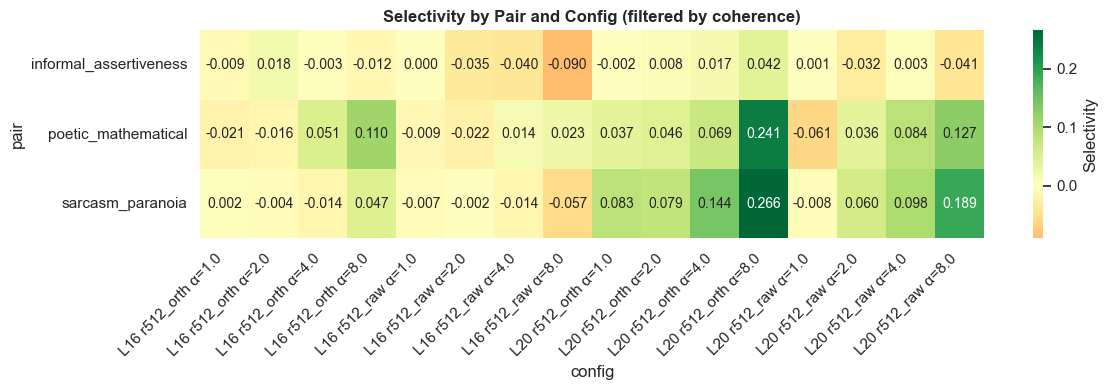

✓ Saved selectivity_heatmap.png


In [65]:
if config_df is not None:
    # Heatmap: pair x config, colored by selectivity
    
    # Create a pivot-like structure for visualization
    pivot_data = []
    
    for _, row in config_df_filtered.iterrows():
        config_str = f"L{int(row['layer'])} {row['variant']} α={row['alpha']:.1f}"
        pivot_data.append({
            "pair": row["pair"],
            "config": config_str,
            "selectivity": row["selectivity"],
        })
    
    pivot_df = pd.DataFrame(pivot_data).pivot(index="pair", columns="config", values="selectivity")
    
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=ax, cbar_kws={"label": "Selectivity"})
    ax.set_title("Selectivity by Pair and Config (filtered by coherence)", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "selectivity_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved selectivity_heatmap.png")

In [ ]:
def mean_scores_for_group(df, group_name, pos_trait, neg_trait, condition):
    """Average pos/neg/coherence scores across all eval_id rows for a group."""
    rows = df[df["group"] == group_name]
    if rows.empty:
        return None

    pos_col = f"score_{pos_trait}|{condition}"
    neg_col = f"score_{neg_trait}|{condition}"
    coh_col = f"score_coherence|{condition}"

    result = {
        "pos_score": rows[pos_col].mean() if pos_col in rows.columns else np.nan,
        "neg_score": rows[neg_col].mean() if neg_col in rows.columns else np.nan,
        "coherence": rows[coh_col].mean() if coh_col in rows.columns else np.nan,
        "n_rows": len(rows),
    }
    return result

# ── Build steered results dataframe ──
steered_rows = []
for group_name in raw_df["group"].unique():
    parsed = parse_steered_group(group_name)
    if parsed is None:
        continue
    scores = mean_scores_for_group(raw_df, group_name, parsed["pos_trait"], parsed["neg_trait"], CONDITION)
    if scores:
        steered_rows.append({**parsed, **scores, "group": group_name})

steered_df = pd.DataFrame(steered_rows)

# ── Build baseline results dataframe ──
baseline_rows = []
for group_name in raw_df["group"].unique():
    parsed = parse_baseline_group(group_name)
    if parsed is None or parsed["seed"] != BASELINE_SEED:
        continue
    if (parsed["pos_trait"], parsed["neg_trait"]) not in PILOT_PAIRS:
        continue
    scores = mean_scores_for_group(raw_df, group_name, parsed["pos_trait"], parsed["neg_trait"], CONDITION)
    if scores:
        baseline_rows.append({**parsed, **scores, "group": group_name})

baseline_df = pd.DataFrame(baseline_rows)

print(f"Steered configs found: {len(steered_df)} (expect 48)")
print(f"Baseline groups found: {len(baseline_df)} (expect 3)")
if not steered_df.empty:
    print("\nSteered sample:")
    print(steered_df[["pair","layer","variant","alpha","pos_score","neg_score","coherence"]].head())
if not baseline_df.empty:
    print("\nBaseline sample:")
    print(baseline_df[["pair","pos_score","neg_score","coherence"]])

Steered configs found: 48 (expect 48)
Baseline groups found: 0 (expect 3)

Steered sample:
                     pair  layer    variant  alpha  pos_score  neg_score  \
0  poetic_mathematical100     16  r512_orth    1.0  83.324798        NaN   
1  poetic_mathematical100     16  r512_orth    2.0  84.363909        NaN   
2  poetic_mathematical100     16  r512_orth    4.0  84.273063        NaN   
3  poetic_mathematical100     16  r512_orth    8.0  83.519152        NaN   
4  poetic_mathematical100     16   r512_raw    1.0  84.017199        NaN   

   coherence  
0  51.544933  
1  52.300456  
2  53.330487  
3  55.226712  
4  51.523057  


## Step 7: Coherence vs Suppression scatter

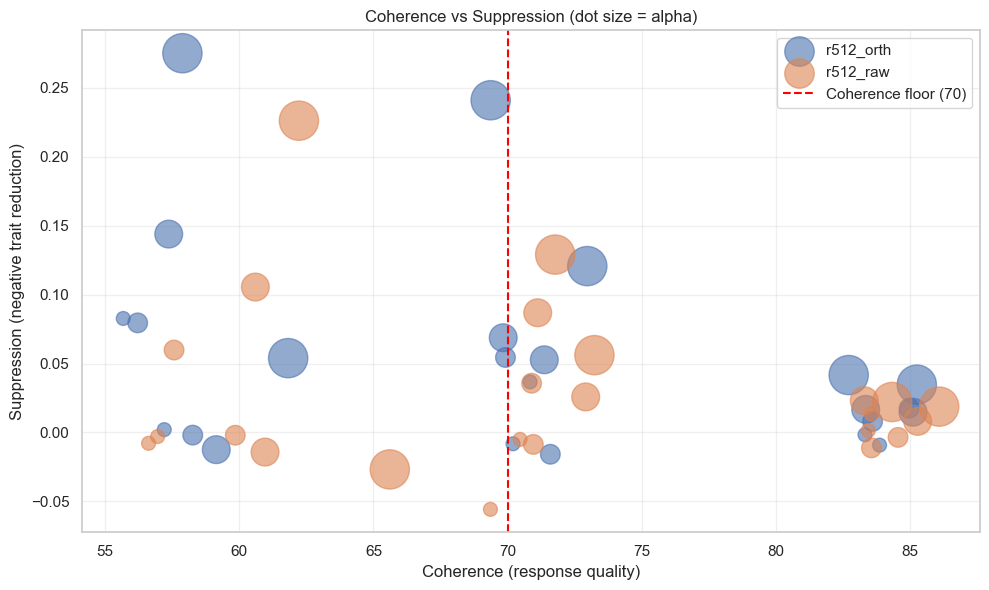

✓ Saved coherence_vs_suppression.png


In [66]:
fig, ax = plt.subplots(figsize=(10, 6))

for variant in config_df_filtered["variant"].unique():
    variant_data = config_df_filtered[config_df_filtered["variant"] == variant]
    ax.scatter(
        variant_data["coherence"],
        variant_data["suppression"],
        s=variant_data["alpha"] * 100,
        alpha=0.6,
        label=variant,
    )

ax.axvline(COHERENCE_FLOOR, color="red", linestyle="--", linewidth=1.5, label=f"Coherence floor ({COHERENCE_FLOOR})")
ax.set_xlabel("Coherence (response quality)")
ax.set_ylabel("Suppression (negative trait reduction)")
ax.set_title("Coherence vs Suppression (dot size = alpha)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "coherence_vs_suppression.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved coherence_vs_suppression.png")

# Summary

In [67]:
summary = config_df_filtered[[
    "pair", "layer", "variant", "alpha",
    "suppression", "collateral", "selectivity",
    "coherence", "ft_coherence", "coherence_delta",
]].sort_values("selectivity", ascending=False)

summary.to_csv(RESULTS_DIR / "pilot_config_summary.csv", index=False)
print("✓ Saved pilot_config_summary.csv\n")
print("\n=== FULL RANKING (by selectivity) ===")
print(summary.to_string(index=False))

✓ Saved pilot_config_summary.csv


=== FULL RANKING (by selectivity) ===
                  pair  layer   variant  alpha  suppression  collateral  selectivity  coherence  ft_coherence  coherence_delta
      sarcasm_paranoia     20 r512_orth    8.0     0.275053    0.009245     0.265809  57.880249     58.311525        -0.431276
   poetic_mathematical     20 r512_orth    8.0     0.240947    0.000000     0.240947  69.368550     68.383504         0.985046
      sarcasm_paranoia     20  r512_raw    8.0     0.226117    0.037402     0.188715  62.223000     58.311525         3.911475
      sarcasm_paranoia     20 r512_orth    4.0     0.143882    0.000000     0.143882  57.370952     58.311525        -0.940573
   poetic_mathematical     20  r512_raw    8.0     0.129035    0.002019     0.127016  71.772600     68.383504         3.389096
   poetic_mathematical     16 r512_orth    8.0     0.120665    0.010203     0.110463  72.968997     68.383504         4.585493
      sarcasm_paranoia     20  r512_ra